In [1]:
#Code from garbage_classification_images and garbage_classification_text from lectures was refered to create this code.
# 1. IMPORTS 
import os
from pathlib import Path
from PIL import Image
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from transformers import BertTokenizer, BertModel
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:

# 2. CONFIG & HYPERPARAMETERS

TRAIN_DIR = '/work/TALC/ensf617_2026w/garbage_data/CVPR_2024_dataset_Train'
VAL_DIR = '/work/TALC/ensf617_2026w/garbage_data/CVPR_2024_dataset_Val'
TEST_DIR = '/work/TALC/ensf617_2026w/garbage_data/CVPR_2024_dataset_Test'

NUM_CLASSES = 4
BATCH_SIZE = 64         
EPOCHS = 10
LEARNING_RATE = 1e-4
MAX_TEXT_LEN = 32
NUM_WORKERS = 2        

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
print("Device:", device)


Device: cuda


In [4]:

# 3. Data Augmentation and Transforms
imagenet_mean = [0.485, 0.456, 0.406] # standard mean for ImageNet pretrained models
imagenet_std  = [0.229, 0.224, 0.225] # standard std for ImageNet pretrained models

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

val_transform = transforms.Compose([ 
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])


In [5]:

#  4. Custom Dataset Class
class GarbageDataset(Dataset):

#   A custom dataset class that loads images and their corresponding text (derived from filenames) for the garbage classification task.
    def __init__(self, root_dir, tokenizer, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.tokenizer = tokenizer
        self.samples = [] 
        # Create class-to-index mapping based on subfolder names
        classes = sorted([d.name for d in self.root_dir.iterdir() if d.is_dir()])
        if not classes:
            raise ValueError(f"No class folders found in {root_dir}")
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
         
        for cls in classes:                                            # iterate through each class folder
            cls_dir = self.root_dir / cls
            for p in cls_dir.iterdir():                                # iterate through each file in the class folder
                if p.suffix.lower() in (".png", ".jpg", ".jpeg"):      # check if it's an image file
                    self.samples.append((str(p), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        # load image
        img = Image.open(img_path).convert("RGB")  
        if self.transform:
            img = self.transform(img)

        # create text from filename 
        text = Path(img_path).stem.replace("_", " ")

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )
        input_ids = encoding["input_ids"].squeeze(0)    
        attention_mask = encoding["attention_mask"].squeeze(0)

        return img, input_ids, attention_mask, label


In [6]:

#  5. Model Definition
class MultiModalModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout_p=0.3):
        super().__init__()
        # Image: pretrained ResNet50 

        try:
            self.resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2) 
        except Exception:
            self.resnet = models.resnet50(pretrained=True)
        self.resnet.fc = nn.Identity() 

        # Text: pretrained BERT
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        # Fusion classifier
        fusion_dim = 2048 + 768 # resnet50 output + bert output
        self.classifier = nn.Sequential( 
            nn.Linear(fusion_dim, 512), 
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(512, num_classes)
        )

    def forward(self, images, input_ids, attention_mask): # forward method takes both image and text inputs
        img_feats = self.resnet(images)  
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_feats = bert_out.pooler_output  
        fused = torch.cat([img_feats, text_feats], dim=1)   # concatenate image and text features
        logits = self.classifier(fused)  # pass through classifier to get final logits
        return logits


In [ ]:

# 6. Dataloaders
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased") # tokenizer for text processing

# Create dataset instances for training, validation, and testing
train_ds = GarbageDataset(TRAIN_DIR, tokenizer, transform=train_transform)
val_ds   = GarbageDataset(VAL_DIR,   tokenizer, transform=val_transform)
test_ds  = GarbageDataset(TEST_DIR,  tokenizer, transform=val_transform)

# Create dataloaders for batching and shuffling
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,pin_memory=True,prefetch_factor=2,persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,pin_memory=True,prefetch_factor=2,persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,pin_memory=True,prefetch_factor=2,persistent_workers=True)

# Print dataset statistics
print(f"Train samples: {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")
print("Classes:", train_ds.class_to_idx)


Train samples: 11629
Validation samples: 1800
Test samples: 3432
Classes: {'Black': 0, 'Blue': 1, 'Green': 2, 'TTR': 3}


In [8]:

# 7. validation Function
def evaluate(model, loader, criterion):  # A function to evaluate the model on a given dataloader and compute average loss and accuracy.
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad(): # no gradients needed for evaluation
        for images, input_ids, masks, labels in loader:
            images = images.to(device)
            input_ids = input_ids.to(device)
            masks = masks.to(device)
            labels = labels.to(device)

            outputs = model(images, input_ids, masks)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total



In [9]:
# 8. SETUP MODEL / LOSS / OPT
model = MultiModalModel(num_classes=NUM_CLASSES).to(device) 
criterion = nn.CrossEntropyLoss() # Cross-entropy loss for multi-class classification
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5) # AdamW optimizer with weight decay for regularization


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:

# 9. TRAIN / VALIDATE loop
best_val_loss = 1e+20
for epoch in range(1, EPOCHS + 1):
    # ---- train ----
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    train_iter = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]", leave=False) 
    for images, input_ids, attention_mask, labels in train_iter: 
        images = images.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # zero gradients before backward pass
        outputs = model(images, input_ids, attention_mask)  
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0) 
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    epoch_train_loss = running_loss / running_total
    epoch_train_acc = running_correct / running_total

    # ---- validate ----
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad(): # no gradients needed for validation
        for images, input_ids, attention_mask, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]", leave=False): 
            images = images.to(device)
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(images, input_ids, attention_mask) 
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item() 
            val_total += labels.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    batches = len(train_loader)
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"{batches}/{batches} - loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}\n")
# ---- SAVE BEST MODEL ----
    if epoch_val_loss < best_val_loss:
        print(f"Saving best model.")
        torch.save(model.state_dict(), "multimodal_garbage_best.pth")
        best_val_loss = epoch_val_loss
    print("----------------------------------------------------------------------------------")  


Epoch 1/10
182/182 - loss: 0.5104 - accuracy: 0.8121 - val_loss: 0.2713 - val_accuracy: 0.9000

Saving best model.
----------------------------------------------------------------------------------


Epoch 2/10
182/182 - loss: 0.2278 - accuracy: 0.9223 - val_loss: 0.2176 - val_accuracy: 0.9328

Saving best model.
----------------------------------------------------------------------------------


Epoch 3/10
182/182 - loss: 0.1368 - accuracy: 0.9553 - val_loss: 0.2392 - val_accuracy: 0.9278

----------------------------------------------------------------------------------


Epoch 4/10
182/182 - loss: 0.0795 - accuracy: 0.9746 - val_loss: 0.2467 - val_accuracy: 0.9389

----------------------------------------------------------------------------------


Epoch 5/10
182/182 - loss: 0.0393 - accuracy: 0.9880 - val_loss: 0.2870 - val_accuracy: 0.9372

----------------------------------------------------------------------------------


Epoch 6/10
182/182 - loss: 0.0371 - accuracy: 0.9881 - val_loss: 0.2970 - val_accuracy: 0.9417

----------------------------------------------------------------------------------


Epoch 7/10
182/182 - loss: 0.0327 - accuracy: 0.9897 - val_loss: 0.3082 - val_accuracy: 0.9367

----------------------------------------------------------------------------------


Epoch 8/10
182/182 - loss: 0.0214 - accuracy: 0.9932 - val_loss: 0.3211 - val_accuracy: 0.9378

----------------------------------------------------------------------------------


Epoch 9/10
182/182 - loss: 0.0234 - accuracy: 0.9926 - val_loss: 0.3450 - val_accuracy: 0.9422

----------------------------------------------------------------------------------


Epoch 10/10
182/182 - loss: 0.0215 - accuracy: 0.9934 - val_loss: 0.3182 - val_accuracy: 0.9444

----------------------------------------------------------------------------------


Testing & Evaluating: 100%|██████████| 54/54 [01:31<00:00,  1.70s/it]


Test Accuracy: 0.8228 or 82.28%

--- Classification Report ---
              precision    recall  f1-score   support

       Black       0.76      0.65      0.70       695
        Blue       0.76      0.90      0.82      1086
       Green       0.93      0.89      0.91       799
         TTR       0.86      0.81      0.83       852

    accuracy                           0.82      3432
   macro avg       0.83      0.81      0.82      3432
weighted avg       0.83      0.82      0.82      3432



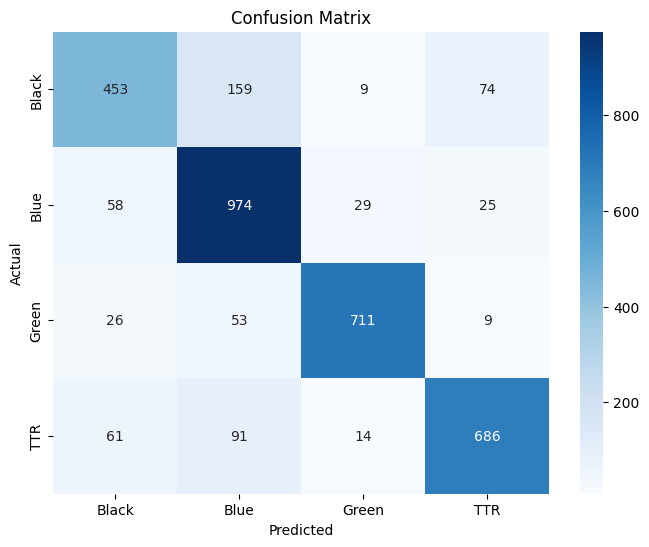


Total incorrect: 608 out of 3432


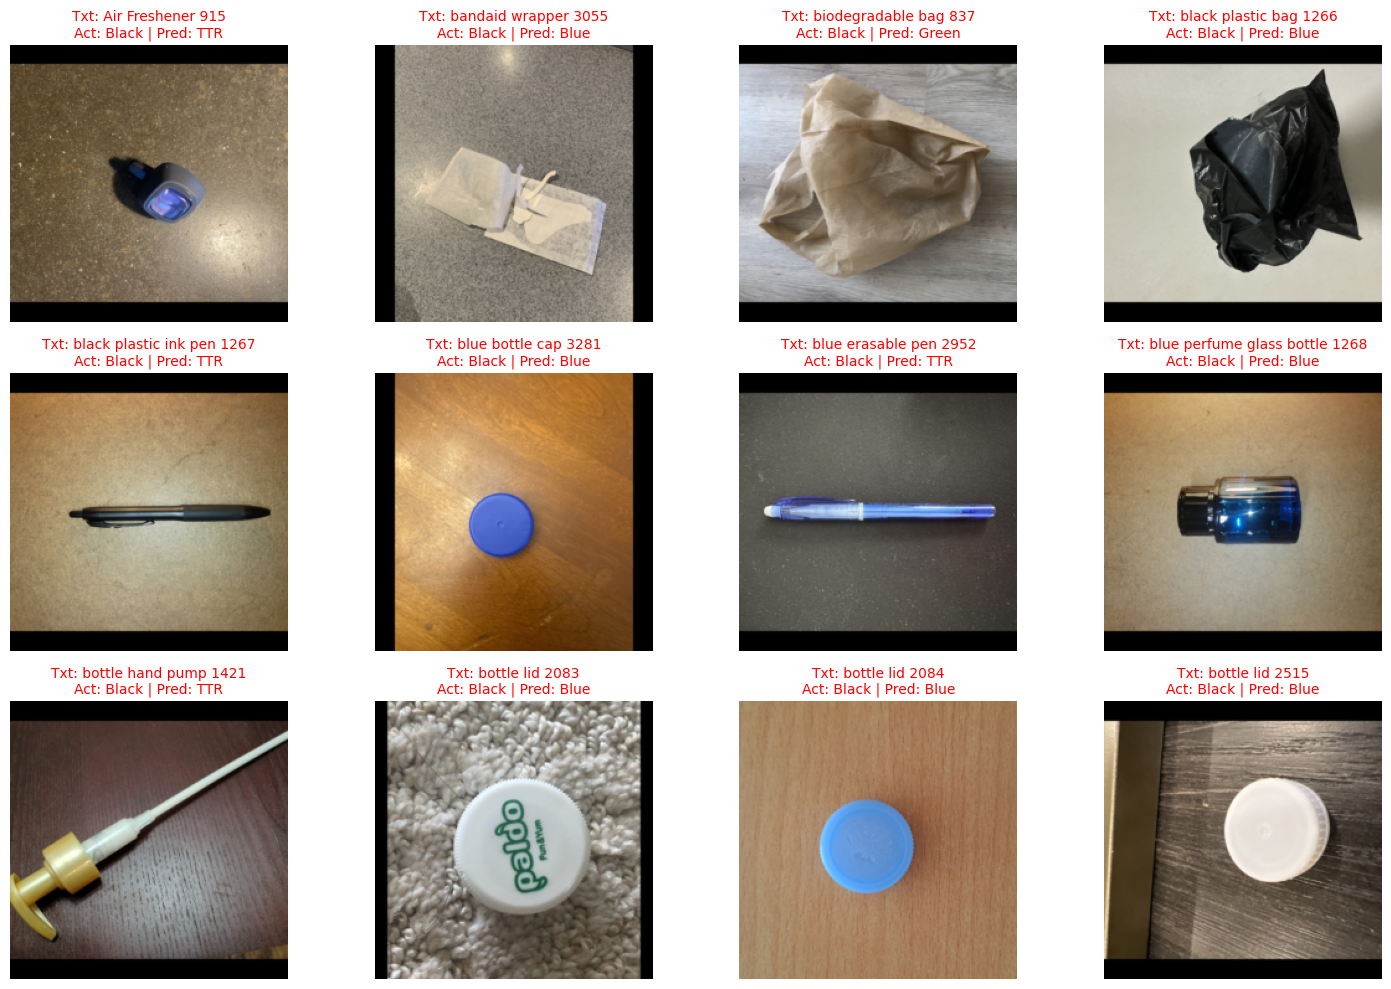

In [11]:
# 10. TESTING & EVALUATION
model.load_state_dict(torch.load("multimodal_garbage_best.pth"))
model.to(device)
model.eval()

all_preds = []
all_labels = []

# getting labels and pritictions
with torch.no_grad():
    for images, input_ids, attention_mask, labels in tqdm(test_loader, desc="Testing & Evaluating"):
        images_gpu = images.to(device)
        input_ids_gpu = input_ids.to(device)
        attention_mask_gpu = attention_mask.to(device)

        outputs = model(images_gpu, input_ids_gpu, attention_mask_gpu) 
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy()) # move predictions to CPU and convert to numpy before storing
        all_labels.extend(labels.numpy())


all_preds = np.array(all_preds)
all_labels = np.array(all_labels) 
class_names = list(test_ds.class_to_idx.keys())

#  METRICS & CONFUSION MATRIX
test_acc = np.mean(all_preds == all_labels)
print(f"\nTest Accuracy: {test_acc:.4f} or {test_acc * 100:.2f}%")

print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds) # compute confusion matrix using true labels and predictions
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#  VISUALIZE FAILURES
def imshow(img_tensor, title=None):
    """Denormalize and show image"""
    img = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array(imagenet_mean) 
    std = np.array(imagenet_std)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)
    if title is not None:
        plt.title(title, color='red', fontsize=10)
    plt.axis('off')


incorrect_indices = np.where(all_preds != all_labels)[0] # get indices of incorrect predictions
print(f"\nTotal incorrect: {len(incorrect_indices)} out of {len(all_labels)}")


plt.figure(figsize=(15, 10))
num_to_show = min(len(incorrect_indices), 12)

for i in range(num_to_show): # loop through the first few incorrect predictions to visualize
    idx = incorrect_indices[i]
    plt.subplot(3, 4, i + 1)
    
    actual_label = class_names[all_labels[idx]]
    pred_label = class_names[all_preds[idx]]

    img_tensor, _, _, _ = test_ds[idx] 
    img_path, _ = test_ds.samples[idx]
    display_text = Path(img_path).stem.replace("_", " ")

    title = f"Txt: {display_text}\nAct: {actual_label} | Pred: {pred_label}"
    imshow(img_tensor, title)

plt.tight_layout()
plt.show()